# Deep learning segmentation of spectrogram in a supervised setting

# load Dataset

In [1]:
process = True

In [2]:
import os
import numpy as np
import json
from pathlib import Path

def load_mask_with_spectrograms(path: str | Path) -> dict:
    path = Path(path)
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


if process == True:

    # List all elements (files and folders)
    elements = os.listdir('data_mask_spectro/')

    X_eeg =  []
    X_spec = []
    Y = []

    for elem in elements:
        if '.json' in elem:
            # load masks and spectrogram
            data = load_mask_with_spectrograms('data_mask_spectro/' + elem)
            # load recording (use try except since can be from 2 different folders)
            try:
                y = np.load('anesthesia_database/' + data['recording'])
            except:
                y = np.load('anesthesia_database_Trousseau/' + data['recording'])
            # load window key names
            list_windows_keys = list(data['windows'].keys())
            # iterate over all windows
            for i in range(len(data['windows'])):
                current_window = data['windows'][list_windows_keys[i]]
                start_s = float(current_window["window_start_s"])
                end_s = float(current_window["window_end_s"])
                fs = int(current_window["fs_hz"])

                start_i = int(round(start_s * fs))
                end_i = int(round(end_s * fs))

                signal = y[start_i : end_i]
                t_signal = np.arange(len(signal)) / fs

                mask = current_window['mask']

                t_spec = current_window['t_spec']
                f_spec = current_window['f_spec']
                spec = np.array(current_window['spectrogram'])

                X_eeg.append(signal)
                X_spec.append(spec)
                Y.append(mask)


    #--- convert to np arrays
    X_eeg = np.array(X_eeg)
    X_spec = np.array(X_spec)
    Y = np.array(Y)

    np.save('X_Y_dataset/X_eeg', X_eeg)
    np.save('X_Y_dataset/X_spec', X_spec)
    np.save('X_Y_dataset/Y', Y)

else:
    X_eeg =  np.load('X_Y_dataset/X_eeg.npy')
    X_spec =  np.load('X_Y_dataset/X_spec.npy')
    Y = np.load('X_Y_dataset/Y.npy')

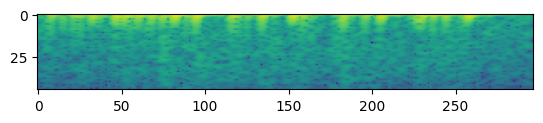

In [4]:
import matplotlib.pyplot as plt

plt.imshow(np.log2(X_spec[0]+ 0.000001))

# Get features and X, Y vectors

In [ ]:
from feature_extractor import extract_features_time_series, extract_features_spectrogram

X = []

fs  = 128
mean, med_mean, q_std, med_q_std, q_linelen, med_q_linelen, q_env, med_q_env, std_env, med_q_std_env  = extract_features_time_series(X_eeg[i], int(fs / 8), Y[i])

ef, ef_recovery, med_ef, med_ef_recovery, prop_delta, prop_alpha, prop_beta, prop_gamma, q_P_tot, med_q_P_tot =  extract_features_spectrogram(f_spec, X_spec[i])

X.append([mean, med_mean, q_std, med_q_std, q_linelen, med_q_linelen, q_env, med_q_env, std_env, med_q_std_env, ef, ef_recovery, med_ef, med_ef_recovery, prop_delta, prop_alpha, prop_beta, prop_gamma, q_P_tot, med_q_P_tot])

ValueError: method must be "linear" or "nearest"

# Utilities

In [48]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tqdm.auto import tqdm

# -------------------------------------------------
# 1) Train / Val / Test split (classic, no stratify)
# -------------------------------------------------
def split_train_val_test(X, y, test_size=0.2, val_size=0.2, random_state=42):
    """
    val_size is the fraction of the *remaining* data after removing test.
    Example: test_size=0.2, val_size=0.2 -> train=64%, val=16%, test=20%.
    """
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=None
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp,
        test_size=val_size,
        random_state=random_state,
        stratify=None
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

# ----------------------------
# Dataset: numpy -> torch
# X: (N, 45, 297) float32
# y: (N, 297) int64 in [0..9]
# ----------------------------
class SpectrogramSegDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        assert X.ndim == 3 and X.shape[1] == 45 and X.shape[2] == 297
        assert y.ndim == 2 and y.shape[1] == 297
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])         # (45, 297)
        y = torch.from_numpy(self.y[idx])         # (297,)
        return x, y


# ----------------------------
# Dice metric (macro Dice)
# for multiclass segmentation over time axis
# pred: (B, T) int64
# target: (B, T) int64
# ----------------------------
@torch.no_grad()
def dice_score_multiclass(pred: torch.Tensor, target: torch.Tensor, num_classes: int, eps: float = 1e-6):
    # pred/target: (B, T)
    B, T = pred.shape
    pred_oh = F.one_hot(pred, num_classes=num_classes).float()       # (B, T, C)
    tgt_oh  = F.one_hot(target, num_classes=num_classes).float()     # (B, T, C)

    # Sum over batch and time
    pred_sum = pred_oh.sum(dim=(0, 1))     # (C,)
    tgt_sum  = tgt_oh.sum(dim=(0, 1))      # (C,)
    inter    = (pred_oh * tgt_oh).sum(dim=(0, 1))  # (C,)

    dice_c = (2.0 * inter + eps) / (pred_sum + tgt_sum + eps)  # (C,)
    macro = dice_c.mean().item()
    return macro, dice_c.cpu().numpy()


# ----------------------------
# Differentiable Dice loss
# logits: (B, T, C)
# target: (B, T)
# ----------------------------
def dice_loss_from_logits(logits: torch.Tensor, target: torch.Tensor, num_classes: int, eps: float = 1e-6):
    probs = torch.softmax(logits, dim=-1)  # (B, T, C)
    tgt_oh = F.one_hot(target, num_classes=num_classes).float()  # (B, T, C)

    # sum over B,T
    inter = (probs * tgt_oh).sum(dim=(0, 1))       # (C,)
    p_sum = probs.sum(dim=(0, 1))                  # (C,)
    t_sum = tgt_oh.sum(dim=(0, 1))                 # (C,)

    dice = (2.0 * inter + eps) / (p_sum + t_sum + eps)  # (C,)
    return 1.0 - dice.mean()  # scalar


class CEDiceLoss(nn.Module):
    def __init__(self, num_classes: int, dice_weight: float = 0.5, class_weights: torch.Tensor | None = None):
        super().__init__()
        self.num_classes = num_classes
        self.dice_weight = dice_weight
        self.ce = nn.CrossEntropyLoss(weight=class_weights)

    def forward(self, logits: torch.Tensor, target: torch.Tensor):
        # logits (B,T,C) -> CE wants (B,C,T)
        ce = self.ce(logits.permute(0, 2, 1), target)
        dl = dice_loss_from_logits(logits, target, self.num_classes)
        return (1.0 - self.dice_weight) * ce + self.dice_weight * dl


# ----------------------------
# Simple train/eval loops
# ----------------------------

# ----------------------------
# Class weights (more stable for heavy imbalance)
# weights_k = 1 / log(c + freq_k)
# where freq_k = count_k / total. (c slightly > 1)
# ----------------------------
def compute_log_inv_class_weights(y_train: np.ndarray, num_classes: int, c: float = 1.02, eps: float = 1e-12) -> np.ndarray:
    flat = y_train.reshape(-1)
    counts = np.bincount(flat, minlength=num_classes).astype(np.float64)
    freq = counts / max(counts.sum(), 1.0)
    weights = 1.0 / (np.log(c + freq) + eps)
    # normalize mean weight over present classes to 1
    present = counts > 0
    if present.any():
        weights = weights / weights[present].mean()
    # missing classes -> weight 0 (won't matter for CE)
    weights[~present] = 0.0
    return weights.astype(np.float32), counts.astype(np.int64)

# ----------------------------
# Multiclass Focal Loss (drop-in replacement for CrossEntropyLoss)
# - helps with imbalance by down-weighting easy examples.
# ----------------------------
class FocalLoss(nn.Module):
    def __init__(self, gamma: float = 2.0, class_weights: torch.Tensor | None = None, reduction: str = "mean"):
        super().__init__()
        self.gamma = gamma
        self.class_weights = class_weights
        if reduction not in ("mean", "sum", "none"):
            raise ValueError("reduction must be 'mean', 'sum', or 'none'")
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        # logits: (B,T,C), target: (B,T)
        # compute per-position CE (no reduction)
        ce = F.cross_entropy(
            logits.permute(0, 2, 1),  # (B,C,T)
            target,
            weight=self.class_weights,
            reduction="none",
        )  # (B,T)

        # pt = exp(-ce) is prob assigned to true class
        pt = torch.exp(-ce)  # (B,T)
        focal = (1.0 - pt).pow(self.gamma) * ce  # (B,T)

        if self.reduction == "mean":
            return focal.mean()
        if self.reduction == "sum":
            return focal.sum()
        return focal

# ----------------------------
# Combined losses
# ----------------------------
class FocalDiceLoss(nn.Module):
    def __init__(self, num_classes: int, dice_weight: float = 0.3, gamma: float = 2.0, class_weights: torch.Tensor | None = None):
        super().__init__()
        self.num_classes = num_classes
        self.dice_weight = dice_weight
        self.focal = FocalLoss(gamma=gamma, class_weights=class_weights, reduction="mean")

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        fl = self.focal(logits, target)
        dl = dice_loss_from_logits(logits, target, self.num_classes)
        return (1.0 - self.dice_weight) * fl + self.dice_weight * dl

class HierarchicalBgThenClassLoss(nn.Module):
    '''
    Two-stage (in one model) loss:
      1) binary: background (class 0) vs non-background (classes 1..C-1)
      2) multiclass among non-background only (masked)

    This is useful when class 0 dominates heavily.
    You can use it with ANY model that outputs logits (B,T,C).
    '''
    def __init__(self, num_classes: int, dice_weight: float = 0.3, gamma: float = 2.0,
                 class_weights: torch.Tensor | None = None, bg_weight: float = 1.0):
        super().__init__()
        self.num_classes = num_classes
        self.dice_weight = dice_weight
        self.bg_weight = bg_weight
        self.focal = FocalLoss(gamma=gamma, class_weights=class_weights, reduction="mean")

        # binary focal for bg vs non-bg (no per-class weights here; bg_weight can compensate)
        self.bin_focal = FocalLoss(gamma=gamma, class_weights=None, reduction="mean")

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        # logits: (B,T,C), target: (B,T)
        B, T, C = logits.shape
        assert C == self.num_classes

        # (1) binary head built from multiclass logits:
        # bg logit = logits[...,0], non-bg logit = logsumexp(logits[...,1:])
        bg_logit = logits[..., 0:1]  # (B,T,1)
        nonbg_logit = torch.logsumexp(logits[..., 1:], dim=-1, keepdim=True)  # (B,T,1)
        bin_logits = torch.cat([bg_logit, nonbg_logit], dim=-1)  # (B,T,2)

        bin_target = (target != 0).long()  # 1 = non-bg, 0 = bg
        bin_loss = self.bin_focal(bin_logits, bin_target) * self.bg_weight

        # (2) multiclass among non-bg only (mask positions where target != 0)
        mask = (target != 0)  # (B,T)
        if mask.any():
            logits_nb = logits[mask]  # (N_nonbg, C)
            target_nb = target[mask]  # (N_nonbg,)
            # focal over original classes (still includes class 0, but target_nb != 0 so OK)
            # add dice computed on full logits for stability
            multi_loss = self.focal(logits, target)
        else:
            multi_loss = torch.tensor(0.0, device=logits.device)

        dl = dice_loss_from_logits(logits, target, self.num_classes)

        # total: encourage correct bg/nonbg + within-class separation + overlap quality
        return 0.5 * bin_loss + 0.5 * ((1.0 - self.dice_weight) * multi_loss + self.dice_weight * dl)

# ----------------------------
# Global Dice helpers (proper evaluation)
# ----------------------------
@torch.no_grad()
def collect_preds_targets_flat(model, loader, device):
    model.eval()
    y_true_all, y_pred_all = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        preds = logits.argmax(dim=-1)
        y_true_all.append(y.detach().cpu())
        y_pred_all.append(preds.detach().cpu())
    y_true = torch.cat(y_true_all, dim=0).reshape(-1)
    y_pred = torch.cat(y_pred_all, dim=0).reshape(-1)
    return y_true, y_pred

def global_macro_dice_from_flat(y_true_flat: torch.Tensor, y_pred_flat: torch.Tensor, num_classes: int, eps: float = 1e-6):
    dice_per_class = torch.zeros(num_classes, dtype=torch.float64)
    for k in range(num_classes):
        true_k = (y_true_flat == k)
        pred_k = (y_pred_flat == k)
        tp = (true_k & pred_k).sum().item()
        fp = ((~true_k) & pred_k).sum().item()
        fn = (true_k & (~pred_k)).sum().item()
        dice_per_class[k] = (2.0 * tp + eps) / (2.0 * tp + fp + fn + eps)
    return float(dice_per_class.mean().item()), dice_per_class.cpu().numpy()

@torch.no_grad()
def eval_epoch_global(model, loader, loss_fn, device, num_classes: int):
    model.eval()
    total_loss = 0.0
    n_seen = 0

    if device.startswith("cuda"):
        torch.cuda.synchronize()
    start = time.perf_counter()

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        loss = loss_fn(logits, y)
        bs = x.size(0)
        total_loss += loss.item() * bs
        n_seen += bs

    y_true, y_pred = collect_preds_targets_flat(model, loader, device)
    global_dice, dice_per_class = global_macro_dice_from_flat(y_true, y_pred, num_classes=num_classes)

    if device.startswith("cuda"):
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    avg_loss = total_loss / max(n_seen, 1)
    return avg_loss, global_dice, dice_per_class, elapsed



def run_one_epoch(model, loader, optimizer, loss_fn, device, num_classes: int, train: bool, desc: str = ""):
    model.train(train)
    total_loss = 0.0
    all_macro_dice = []
    n_seen = 0

    if device.startswith("cuda"):
        torch.cuda.synchronize()
    start = time.perf_counter()

    pbar = tqdm(loader, desc=desc, leave=False)
    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        bs = x.size(0)
        n_seen += bs

        with torch.set_grad_enabled(train):
            logits = model(x)  # (B, T, C)
            loss = loss_fn(logits, y)

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * bs

        pred = logits.argmax(dim=-1)  # (B, T)
        macro_dice, _ = dice_score_multiclass(pred, y, num_classes=num_classes)
        all_macro_dice.append(macro_dice)

        # running stats for display
        run_loss = total_loss / n_seen
        run_dice = float(np.mean(all_macro_dice))
        pbar.set_postfix(loss=f"{run_loss:.4f}", dice=f"{run_dice:.4f}")

    if device.startswith("cuda"):
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    avg_loss = total_loss / len(loader.dataset)
    avg_macro_dice = float(np.mean(all_macro_dice)) if all_macro_dice else float("nan")
    return avg_loss, avg_macro_dice, elapsed



def compute_confusion_matrix(model, loader, device, num_classes):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            preds = logits.argmax(dim=-1)

            all_preds.append(preds.cpu().numpy())
            all_targets.append(y.cpu().numpy())

    all_preds = np.concatenate(all_preds).reshape(-1)
    all_targets = np.concatenate(all_targets).reshape(-1)

    cm = confusion_matrix(
        all_targets,
        all_preds,
        labels=list(range(num_classes))
    )

    return cm


def plot_confusion_matrix(cm, class_names, normalize=True):
    cm_plot = cm.astype(np.float64)

    if normalize:
        row_sums = cm_plot.sum(axis=1, keepdims=True)
        cm_plot = np.divide(cm_plot, row_sums, where=row_sums != 0)

    plt.figure(figsize=(8, 7))
    plt.imshow(cm_plot, interpolation="nearest")
    plt.title("Confusion Matrix" + (" (Normalized)" if normalize else ""))
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    plt.xlabel("Predicted")
    plt.ylabel("True")

    # Annotate cells
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            value = cm_plot[i, j]
            text = f"{value:.2f}" if normalize else f"{int(cm[i, j])}"
            plt.text(j, i, text, ha="center", va="center")

    plt.tight_layout()
    plt.show()



# ----------------------------
# Global (dataset-level) Dice helpers
# ----------------------------
@torch.no_grad()
def collect_preds_targets(model, loader, device):
    """Collect flattened predictions/targets over a loader."""
    model.eval()
    y_true_all = []
    y_pred_all = []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)   # (B, T)
        logits = model(x)                      # (B, T, C)
        preds = logits.argmax(dim=-1)          # (B, T)
        y_true_all.append(y.detach().cpu())
        y_pred_all.append(preds.detach().cpu())
    y_true = torch.cat(y_true_all, dim=0).reshape(-1)  # (N_frames,)
    y_pred = torch.cat(y_pred_all, dim=0).reshape(-1)  # (N_frames,)
    return y_true, y_pred


def global_macro_dice_from_flat(y_true_flat: torch.Tensor, y_pred_flat: torch.Tensor, num_classes: int, eps: float = 1e-6):
    """Compute macro Dice from flattened vectors (global TP/FP/FN per class)."""
    dice_per_class = torch.zeros(num_classes, dtype=torch.float64)
    for k in range(num_classes):
        true_k = (y_true_flat == k)
        pred_k = (y_pred_flat == k)
        tp = (true_k & pred_k).sum().item()
        fp = ((~true_k) & pred_k).sum().item()
        fn = (true_k & (~pred_k)).sum().item()
        dice_per_class[k] = (2.0 * tp + eps) / (2.0 * tp + fp + fn + eps)
    return float(dice_per_class.mean().item()), dice_per_class.cpu().numpy()


@torch.no_grad()
def eval_epoch_global(model, loader, loss_fn, device, num_classes: int, desc: str = ""):
    """
    Evaluate average loss (sample-weighted) and GLOBAL macro Dice over the whole loader.
    Returns: avg_loss, global_macro_dice, dice_per_class, elapsed_seconds
    """
    model.eval()
    total_loss = 0.0
    n_seen = 0

    if device.startswith("cuda"):
        torch.cuda.synchronize()
    start = time.perf_counter()

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        loss = loss_fn(logits, y)
        bs = x.size(0)
        total_loss += loss.item() * bs
        n_seen += bs

    # collect preds/targets for global dice (extra forward pass, but correct + simple)
    y_true, y_pred = collect_preds_targets(model, loader, device)
    global_dice, dice_per_class = global_macro_dice_from_flat(y_true, y_pred, num_classes=num_classes)

    if device.startswith("cuda"):
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    avg_loss = total_loss / max(n_seen, 1)
    return avg_loss, global_dice, dice_per_class, elapsed


## Model {22D-CN encoder  +  1D temporal head}

_Temporal head is the decoder here ?_

In [49]:
class ConvBlock2D(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=k, padding=p),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=k, padding=p),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)


class TemporalHead1D(nn.Module):
    """
    Input: (B, F, T) features
    Output: (B, T, C)
    """
    def __init__(self, in_ch, hidden=128, num_classes=10, depth=4, dropout=0.1):
        super().__init__()
        layers = []
        ch = in_ch
        for i in range(depth):
            layers += [
                nn.Conv1d(ch, hidden, kernel_size=5, padding=2, dilation=1),
                nn.BatchNorm1d(hidden),
                nn.GELU(),
                nn.Dropout(dropout),
            ]
            ch = hidden
        self.backbone = nn.Sequential(*layers)
        self.classifier = nn.Conv1d(hidden, num_classes, kernel_size=1)

    def forward(self, x):
        # x: (B, F, T)
        h = self.backbone(x)           # (B, hidden, T)
        out = self.classifier(h)       # (B, C, T)
        return out.permute(0, 2, 1)    # (B, T, C)


class BaselineSpecSeg(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Input x: (B, 45, 297)
        self.enc = nn.Sequential(
            ConvBlock2D(1, 32),
            nn.MaxPool2d(kernel_size=(2, 2)),   # freq 45->22, time 297->148
            ConvBlock2D(32, 64),
            nn.MaxPool2d(kernel_size=(2, 2)),   # freq 22->11, time 148->74
            ConvBlock2D(64, 128),
        )
        # We will reduce freq by mean pooling -> (B, 128, T')
        self.head = TemporalHead1D(in_ch=128, hidden=128, num_classes=num_classes, depth=4)

    def forward(self, x):
        # x: (B, 45, 297)
        x = x.unsqueeze(1)        # (B, 1, 45, 297)
        h = self.enc(x)           # (B, 128, F', T') with F'≈11, T'≈74
        h = h.mean(dim=2)         # (B, 128, T')
        # upsample to T=297
        h = F.interpolate(h, size=297, mode="linear", align_corners=False)  # (B, 128, 297)
        logits = self.head(h)     # (B, 297, C)
        return logits
    


# NOTE:  what  are logits
# NOTE:  should i  add  a layer in aselineSpecSEg


##  Model {2DCNN + 2 head to choose}

In [50]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock2D(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=k, padding=p),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=k, padding=p),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
        )
    def forward(self, x):
        return self.net(x)

class SpecEncoder2D(nn.Module):
    """
    Input:  (B, 45, 297)
    Output: (B, C, 297) after collapsing freq + upsampling time
    """
    def __init__(self, out_ch=128):
        super().__init__()
        self.enc = nn.Sequential(
            ConvBlock2D(1, 32),
            nn.MaxPool2d((2, 2)),   # (45,297)->(~22,~148)
            ConvBlock2D(32, 64),
            nn.MaxPool2d((2, 2)),   # (~22,~148)->(~11,~74)
            ConvBlock2D(64, out_ch),
        )
        self.out_ch = out_ch

    def forward(self, x):
        # x: (B,45,297)
        x = x.unsqueeze(1)     # (B,1,45,297)
        h = self.enc(x)        # (B,C,F',T')
        h = h.mean(dim=2)      # (B,C,T')
        h = F.interpolate(h, size=297, mode="linear", align_corners=False)  # (B,C,297)
        return h


In [51]:
class TemporalHeadLinear(nn.Module):
    def __init__(self, in_ch, num_classes=10):
        super().__init__()
        self.classifier = nn.Conv1d(in_ch, num_classes, kernel_size=1)

    def forward(self, h):
        # h: (B,C,297)
        logits = self.classifier(h)          # (B,num_classes,297)
        return logits.permute(0, 2, 1)       # (B,297,C)

class SpecSeg_2DCNN_LinearHead(nn.Module):
    def __init__(self, num_classes=10, enc_ch=128):
        super().__init__()
        self.encoder = SpecEncoder2D(out_ch=enc_ch)
        self.head = TemporalHeadLinear(in_ch=enc_ch, num_classes=num_classes)

    def forward(self, x):
        h = self.encoder(x)      # (B,enc_ch,297)
        return self.head(h)      # (B,297,C)


In [52]:
class TemporalHeadTCN(nn.Module):
    """
    A small temporal Conv1D stack (context + smoothing).
    """
    def __init__(self, in_ch, hidden=128, num_classes=10, depth=4, kernel_size=5, dropout=0.1):
        super().__init__()
        layers = []
        ch = in_ch
        pad = kernel_size // 2
        for _ in range(depth):
            layers += [
                nn.Conv1d(ch, hidden, kernel_size=kernel_size, padding=pad),
                nn.BatchNorm1d(hidden),
                nn.GELU(),
                nn.Dropout(dropout),
            ]
            ch = hidden
        self.backbone = nn.Sequential(*layers)
        self.classifier = nn.Conv1d(hidden, num_classes, kernel_size=1)

    def forward(self, h):
        # h: (B,C,297)
        z = self.backbone(h)                # (B,hidden,297)
        logits = self.classifier(z)         # (B,C,297) where C=num_classes
        return logits.permute(0, 2, 1)      # (B,297,C)

class SpecSeg_2DCNN_TCNHead(nn.Module):
    def __init__(self, num_classes=10, enc_ch=128, head_hidden=128, head_depth=4):
        super().__init__()
        self.encoder = SpecEncoder2D(out_ch=enc_ch)
        self.head = TemporalHeadTCN(
            in_ch=enc_ch, hidden=head_hidden, num_classes=num_classes, depth=head_depth
        )

    def forward(self, x):
        h = self.encoder(x)      # (B,enc_ch,297)
        return self.head(h)      # (B,297,C)


#  Model {CNN14 (PANNS) feature extractor (pretrained) + temporal head}

In [53]:
class CNN14_PANNs_FeatureSeg(nn.Module):
    """
    Uses PANNs CNN14 via panns_inference SoundEventDetection.
    We pull *framewise* features, then learn a temporal head to predict your 10 classes.

    IMPORTANT:
    - PANNs expects raw audio at 32kHz in the reference usage.
    - If you ONLY have spectrograms (45x297), pretrained PANNs won't match perfectly.
      Best is to keep raw audio and generate features inside the model.

    Below I provide two forward paths:
    (A) forward_from_audio: recommended (raw waveform)
    (B) forward_from_spectrogram: fallback (learnable adapter to mimic expected shape)
    """

    def __init__(self, num_classes=10, device="cuda"):
        super().__init__()
        self.num_classes = num_classes
        self.device_str = device

        # Lazy import so code doesn't crash if you only run baseline/AST
        import panns_inference
        from panns_inference import SoundEventDetection

        self.sed = SoundEventDetection(checkpoint_path=None, device=device)
        # self.sed.inference(audio) returns framewise_output for AudioSet classes (527)
        # We'll treat that as framewise features, then project to 10 classes.

        # A small temporal projection head: 527 -> hidden -> 10
        self.proj = nn.Sequential(
            nn.Conv1d(527, 256, kernel_size=1),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Conv1d(256, num_classes, kernel_size=1),
        )

    @torch.no_grad()
    def _panns_framewise_from_audio(self, audio_32k: np.ndarray) -> torch.Tensor:
        """
        audio_32k: numpy float waveform (B, samples) sampled at 32000Hz
        returns: torch float tensor (B, T_panns, 527)
        """
        framewise = self.sed.inference(audio_32k)  # numpy (B, T_panns, 527)
        return torch.from_numpy(framewise).float()

    def forward_from_audio(self, audio_32k: np.ndarray) -> torch.Tensor:
        """
        Returns logits (B, 297, 10)
        """
        feats = self._panns_framewise_from_audio(audio_32k).to(next(self.parameters()).device)  # (B, Tp, 527)
        feats = feats.permute(0, 2, 1)  # (B, 527, Tp)

        # project to 10
        logits = self.proj(feats)  # (B, 10, Tp)

        # upsample to 297 frames to match your mask length
        logits = F.interpolate(logits, size=297, mode="linear", align_corners=False)  # (B, 10, 297)
        return logits.permute(0, 2, 1)  # (B, 297, 10)

    def forward_from_spectrogram(self, x_spec: torch.Tensor) -> torch.Tensor:
        """
        Fallback if you *only* have spectrograms.
        Here we DO NOT use PANNs properly (since PANNs is pretrained on audio->logmel inside).
        So instead we learn a small adapter and still keep the same temporal head.

        x_spec: (B, 45, 297)
        returns logits: (B, 297, 10)
        """
        # Adapter: (45,297)-> "fake" 527-dim per frame features
        # (This is no longer truly pretrained CNN14; it's a compatibility fallback.)
        h = x_spec  # (B,45,297)
        h = nn.functional.layer_norm(h, normalized_shape=h.shape[1:])  # quick normalize
        h = h.permute(0, 2, 1)  # (B,297,45)

        # simple MLP to 527 dims to reuse same proj head
        h = h.reshape(-1, 45)
        h = F.gelu(nn.Linear(45, 256, device=h.device)(h))
        h = nn.Linear(256, 527, device=h.device)(h)
        h = h.view(x_spec.size(0), 297, 527).permute(0, 2, 1)  # (B,527,297)

        logits = self.proj(h)  # (B,10,297)
        return logits.permute(0, 2, 1)

    def forward(self, x):
        # For consistency with the baseline trainer, assume x is spectrogram.
        return self.forward_from_spectrogram(x)



# NOTE: where are the weights blocked for training on the CNN14  
# NOTE: doc says could enter as raw eeg too

# MODEL {AST  feature extractor (pretrained)  + temporal head}

In [54]:
from transformers import ASTModel, ASTConfig  # pip install transformers

class ASTFeatureSeg(nn.Module):
    """
    AST as a feature extractor + temporal head for 1D time segmentation.

    This is a *practical* adapter approach:
    - We resize spectrogram to (128, 1024) (mel x frames).
    - Feed to ASTModel (as if it were log-mel).
    - Convert token sequence -> time sequence -> upsample to 297 -> classify.

    You may want to try these checkpoints:
      - "MIT/ast-finetuned-audioset-10-10-0.4593" (common)
    (Exact checkpoint choice depends on availability; any ASTModel-compatible one works.)
    """
    def __init__(self, checkpoint="MIT/ast-finetuned-audioset-10-10-0.4593", num_classes=10):
        super().__init__()
        self.ast = ASTModel.from_pretrained(checkpoint)
        hidden = self.ast.config.hidden_size

        # temporal head on extracted time features
        self.temporal = nn.Sequential(
            nn.Conv1d(hidden, 256, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Conv1d(256, num_classes, kernel_size=1),
        )

    def forward(self, x):
        """
        x: (B, 45, 297)
        returns: logits (B, 297, 10)
        """
        B, Freq, T = x.shape

        # Resize to (B, 128, 1024) then add channel dim to match AST expectations
        # AST expects input_values shape (B, 1024, 128) in HF implementation for log-mel features.
        # We'll create (B, 128, 1024) then transpose.
        x2 = x.unsqueeze(1)  # (B,1,45,297)
        x2 = F.interpolate(x2, size=(128, 1024), mode="bilinear", align_corners=False)  # (B,1,128,1024)
        x2 = x2.squeeze(1)  # (B,128,1024)
        input_values = x2.transpose(1, 2)  # (B,1024,128)

        out = self.ast(input_values=input_values)
        # out.last_hidden_state: (B, tokens, hidden)
        hs = out.last_hidden_state

        # Drop CLS token if present (AST uses a CLS token)
        # Many ViT-style models: first token is CLS
        hs = hs[:, 1:, :]  # (B, tokens-1, hidden)

        # We need a "time axis". Tokens correspond to 2D patches (time x freq).
        # We'll approximate:
        # - reshape tokens into (B, H_patches, W_patches, hidden) if possible,
        # - average over freq patches to get (B, W_patches, hidden) as time sequence.
        #
        # We infer patch grid sizes from config:
        patch = self.ast.config.patch_size  # usually 16
        # After resize: frames=1024, mel=128
        # patches along time ~ 1024/patch, along freq ~ 128/patch
        w = 1024 // patch
        h = 128 // patch
        tokens = hs.shape[1]
        # If mismatch due to stride/overlap specifics, fall back to treating tokens as 1D sequence
        if tokens == h * w:
            hs2 = hs.view(B, h, w, -1)          # (B,h,w,hidden)
            time_feat = hs2.mean(dim=1)         # (B,w,hidden)
        else:
            # fallback: just treat token sequence as time-like and interpolate later
            time_feat = hs                      # (B,tokens,hidden)

        # Now time_feat: (B, W', hidden)
        time_feat = time_feat.permute(0, 2, 1)  # (B, hidden, W')

        # Upsample to 297
        time_feat = F.interpolate(time_feat, size=297, mode="linear", align_corners=False)  # (B,hidden,297)

        logits = self.temporal(time_feat)  # (B,10,297)
        return logits.permute(0, 2, 1)     # (B,297,10)


## Model {U-net + temporal head}

In [55]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
        )
    def forward(self, x):
        return self.net(x)

class Down(nn.Module):
    """
    Downsample mostly along frequency:
    pool=(2,1) halves freq, keeps time.
    """
    def __init__(self, in_ch, out_ch, pool=(2,1)):
        super().__init__()
        self.pool = nn.MaxPool2d(pool)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x):
        return self.conv(self.pool(x))

class Up(nn.Module):
    """
    Upsample to match skip connection shape, then DoubleConv.
    Uses bilinear upsampling for stability.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x, skip):
        # x: decoder feature, skip: encoder feature
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


In [56]:
class SpecUNetTemporal(nn.Module):
    """
    2D U-Net over (freq,time) with skip connections,
    then temporal head for per-time segmentation.
    """
    def __init__(self, num_classes=10, base=32, head_hidden=128, head_depth=3):
        super().__init__()
        self.inc  = DoubleConv(1, base)          # (B, base, 45, 297)

        # Downsample frequency more than time (pool=(2,1))
        self.down1 = Down(base,   base*2, pool=(2,1))  # freq ~45->22
        self.down2 = Down(base*2, base*4, pool=(2,1))  # 22->11
        self.down3 = Down(base*4, base*8, pool=(2,1))  # 11->5

        self.bot = DoubleConv(base*8, base*8)

        # Decoder with skip connections
        self.up3 = Up(base*8 + base*8, base*4)
        self.up2 = Up(base*4 + base*4, base*2)
        self.up1 = Up(base*2 + base*2, base)

        self.out_ch = base  # final decoded channels

        # Temporal head takes (B, base, T) after collapsing freq
        self.head = TemporalHead1D(
            in_ch=self.out_ch,
            hidden=head_hidden,
            num_classes=num_classes,
            depth=head_depth,
            kernel_size=5,
            dropout=0.1
        )

    def forward(self, x):
        # x: (B,45,297)
        x = x.unsqueeze(1)          # (B,1,45,297)

        x1 = self.inc(x)            # (B,base,45,297)
        x2 = self.down1(x1)         # (B,2base,~22,297)
        x3 = self.down2(x2)         # (B,4base,~11,297)
        x4 = self.down3(x3)         # (B,8base,~5,297)

        xb = self.bot(x4)           # (B,8base,~5,297)

        y3 = self.up3(xb, x3)       # (B,4base,~11,297)
        y2 = self.up2(y3, x2)       # (B,2base,~22,297)
        y1 = self.up1(y2, x1)       # (B,base,45,297)

        # Collapse frequency -> (B, base, 297)
        h = y1.mean(dim=2)

        # Temporal head -> (B, 297, num_classes)
        logits = self.head(h)

        return logits


In [57]:
class TemporalHead1D(nn.Module):
    def __init__(self, in_ch, hidden=128, num_classes=10, depth=3, kernel_size=5, dropout=0.1):
        super().__init__()
        pad = kernel_size // 2
        layers = []
        ch = in_ch
        for _ in range(depth):
            layers += [
                nn.Conv1d(ch, hidden, kernel_size=kernel_size, padding=pad),
                nn.BatchNorm1d(hidden),
                nn.GELU(),
                nn.Dropout(dropout),
            ]
            ch = hidden
        self.backbone = nn.Sequential(*layers)
        self.classifier = nn.Conv1d(hidden, num_classes, kernel_size=1)

    def forward(self, x):
        # x: (B, C, T)
        z = self.backbone(x)               # (B, hidden, T)
        logits = self.classifier(z)        # (B, num_classes, T)
        return logits.permute(0, 2, 1)     # (B, T, C)


Epoch 79/100 | train loss 0.5758 | train dice batch 0.7070 vs global 0.7745 | val loss 0.6694 val dice(global) 0.6829 | epoch time 1s | ETA 26s
Best val dice(global): 0.7034 (epoch 70) | no-improve 9/9


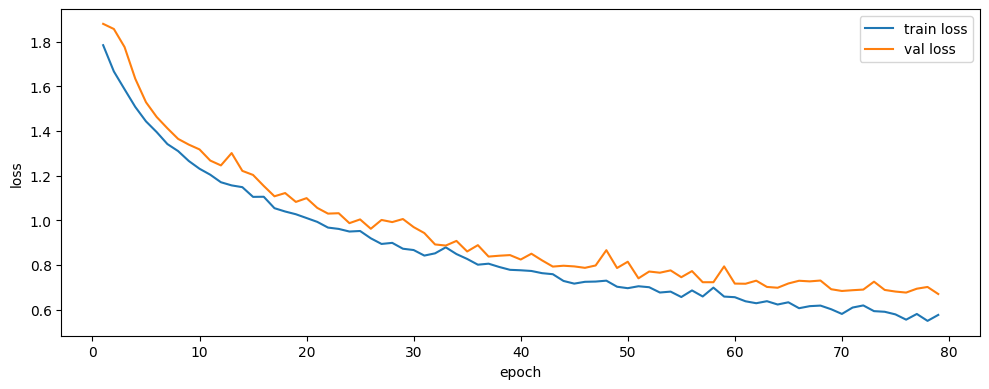

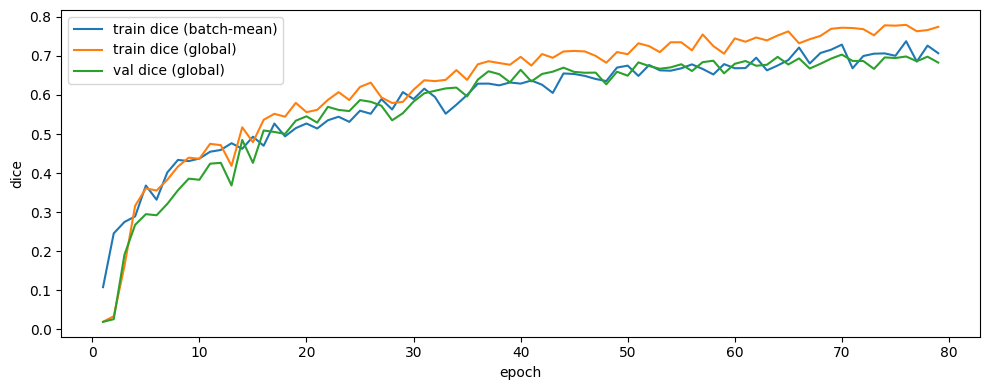

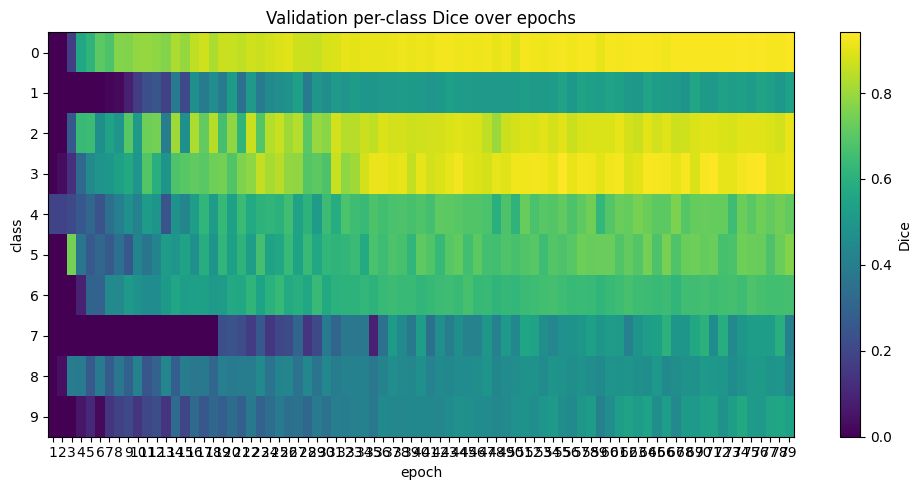

Val per-class Dice (latest): [0.938 0.539 0.911 0.915 0.716 0.765 0.663 0.409 0.435 0.54 ]
Early stopping: no improvement for 9 epochs.
Loaded best model from epoch 70 (val dice(global)=0.7034).

FINAL TEST | loss 0.6643 dice(global) 0.6803 | time 0s
Test per-class Dice: [0.906 0.528 0.818 0.912 0.713 0.922 0.696 0.351 0.391 0.565]


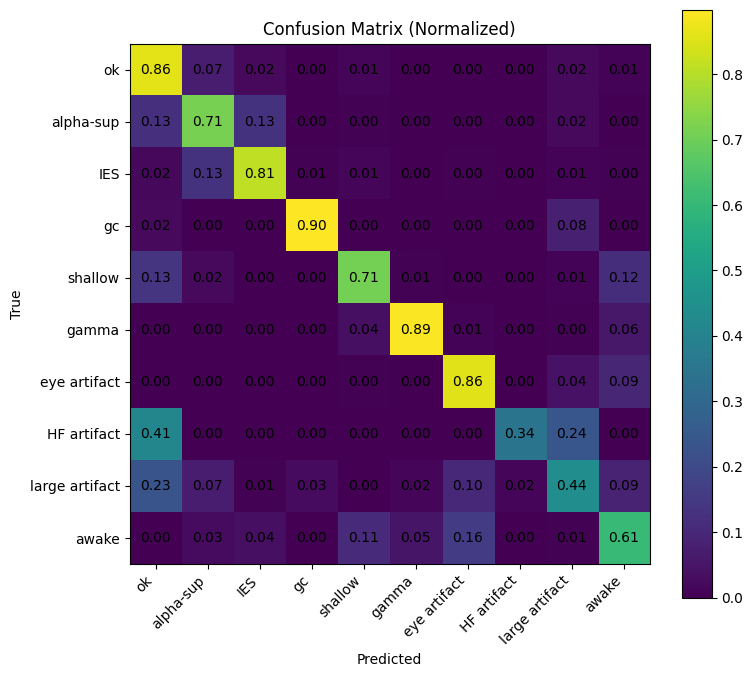

In [58]:

# -------------------------------------------------
# 2) Main training script (with progress, timing, ETA, live curves)
# Also compares train Dice (batch-mean) vs train Dice (global) each epoch.
# -------------------------------------------------
from IPython.display import clear_output

device = "cuda" if torch.cuda.is_available() else "cpu"
num_classes = 10
epochs = 100
patience = 9            # early stopping on VAL global dice
plot_every = 1          # update plots every N epochs

# X_spec: (N,45,297), Y: (N,297) numpy arrays
X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(
    X_spec, Y,
    test_size=0.2,
    val_size=0.2,
    random_state=42
)

# Log transform
X_train = np.log1p(X_train + 0.00000000001)
X_val   = np.log1p(X_val + 0.00000000001)
X_test  = np.log1p(X_test + 0.00000000001)

# Normalize using TRAIN statistics
mean = X_train.mean()
std = X_train.std() + 1e-8

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

print("Shapes:")
print("  Train:", X_train.shape, y_train.shape)
print("  Val:  ", X_val.shape, y_val.shape)
print("  Test: ", X_test.shape, y_test.shape)

# Build datasets/loaders
train_ds = SpectrogramSegDataset(X_train, y_train)
val_ds   = SpectrogramSegDataset(X_val, y_val)
test_ds  = SpectrogramSegDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

# Pick one model:
#model = BaselineSpecSeg(num_classes=num_classes).to(device)
model  =  SpecSeg_2DCNN_LinearHead(num_classes =  num_classes).to(device)
# model = CNN14_PANNs_FeatureSeg(num_classes=num_classes, device=device).to(device)
# model = ASTFeatureSeg(num_classes=num_classes).to(device)

# -------------------------------------------------
# 3) Class weights from TRAIN ONLY (log-inverse; stable for heavy imbalance)
# -------------------------------------------------
weights_np, counts_np = compute_log_inv_class_weights(y_train, num_classes=num_classes, c=1.02)
print("Train class counts:", counts_np)
print("Train class weights (log-inv):", weights_np)

class_weights = torch.tensor(weights_np, dtype=torch.float32).to(device)

# -------------------------------------------------
# 3b) Loss choice
# - start with focal+diceloss (recommended for imbalance)
# - or switch back to CE+Dice
# - or try hierarchical background-vs-nonbg then class
# -------------------------------------------------
USE_FOCAL = False
USE_HIERARCHICAL = False  # set True to use bg-vs-nonbg + multiclass loss

dice_weight = 0.3
focal_gamma = 2.0

if USE_HIERARCHICAL:
    loss_fn = HierarchicalBgThenClassLoss(
        num_classes=num_classes,
        dice_weight=dice_weight,
        gamma=focal_gamma,
        class_weights=class_weights,
        bg_weight=1.0
    )
elif USE_FOCAL:
    loss_fn = FocalDiceLoss(
        num_classes=num_classes,
        dice_weight=dice_weight,
        gamma=focal_gamma,
        class_weights=class_weights
    )
else:
    loss_fn = CEDiceLoss(
        num_classes=num_classes,
        dice_weight=dice_weight,
        class_weights=class_weights
    )
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

def format_seconds(s: float) -> str:
    s = int(round(s))
    h = s // 3600
    m = (s % 3600) // 60
    sec = s % 60
    if h > 0:
        return f"{h}h {m:02d}m {sec:02d}s"
    if m > 0:
        return f"{m}m {sec:02d}s"
    return f"{sec}s"

def plot_history(hist):
    epochs_axis = np.arange(1, len(hist["train_loss"]) + 1)

    plt.figure(figsize=(10, 4))
    plt.plot(epochs_axis, hist["train_loss"], label="train loss")
    plt.plot(epochs_axis, hist["val_loss"], label="val loss")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs_axis, hist["train_dice_batch"], label="train dice (batch-mean)")
    plt.plot(epochs_axis, hist["train_dice_global"], label="train dice (global)")
    plt.plot(epochs_axis, hist["val_dice_global"], label="val dice (global)")
    plt.xlabel("epoch"); plt.ylabel("dice"); plt.legend(); plt.tight_layout()
    plt.show()


    # Val per-class Dice heatmap (rows=classes, cols=epochs)
    if len(hist.get("val_dice_per_class", [])) > 0:
        mat = np.stack(hist["val_dice_per_class"], axis=1)  # (C, E)
        plt.figure(figsize=(10, 5))
        plt.imshow(mat, aspect="auto")
        plt.colorbar(label="Dice")
        plt.xlabel("epoch")
        plt.ylabel("class")
        plt.title("Validation per-class Dice over epochs")
        plt.yticks(np.arange(mat.shape[0]))
        plt.xticks(np.arange(mat.shape[1]), np.arange(1, mat.shape[1] + 1))
        plt.tight_layout()
        plt.show()
# -------------------------------------------------
# 4) Train using VAL GLOBAL Dice for model selection
#    and compute TRAIN GLOBAL Dice at epoch end for comparison
# -------------------------------------------------
history = {
    "train_loss": [],
    "train_dice_batch": [],
    "train_dice_global": [],
    "val_loss": [],
    "val_dice_global": [],
    "val_dice_per_class": [],
    "train_dice_per_class": [],
    "epoch_time": [],
}

best_val = -1.0
best_state = None
best_epoch = -1
no_improve = 0

for epoch in range(1, epochs + 1):
    # Train epoch (shows tqdm progress); returns batch-mean dice + elapsed
    tr_loss, tr_dice_batch, tr_time = run_one_epoch(
        model, train_loader, optimizer, loss_fn, device, num_classes, train=True, desc=f"train {epoch}/{epochs}"
    )

    # Compute TRAIN global dice at epoch end (for comparison)
    tr_loss_eval, tr_dice_global, tr_dice_per_class, tr_eval_time = eval_epoch_global(
        model, train_loader, loss_fn, device, num_classes
    )

    # Validate with GLOBAL dice
    va_loss, va_dice_global, va_dice_per_class, va_time = eval_epoch_global(
        model, val_loader, loss_fn, device, num_classes
    )

    epoch_time = tr_time + tr_eval_time + va_time

    history["train_loss"].append(tr_loss)
    history["train_dice_batch"].append(tr_dice_batch)
    history["train_dice_global"].append(tr_dice_global)
    history["train_dice_per_class"].append(tr_dice_per_class)
    history["val_loss"].append(va_loss)
    history["val_dice_global"].append(va_dice_global)
    history["val_dice_per_class"].append(va_dice_per_class)
    history["epoch_time"].append(epoch_time)

    # Save best checkpoint by validation GLOBAL Dice
    if va_dice_global > best_val:
        best_val = va_dice_global
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    # ETA
    avg_epoch_time = float(np.mean(history["epoch_time"]))
    remaining = epochs - epoch
    eta = remaining * avg_epoch_time

    # Display
    if epoch % plot_every == 0:
        clear_output(wait=True)
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {tr_loss:.4f} | "
            f"train dice batch {tr_dice_batch:.4f} vs global {tr_dice_global:.4f} | "
            f"val loss {va_loss:.4f} val dice(global) {va_dice_global:.4f} | "
            f"epoch time {format_seconds(epoch_time)} | ETA {format_seconds(eta)}"
        )
        print(f"Best val dice(global): {best_val:.4f} (epoch {best_epoch}) | no-improve {no_improve}/{patience}")
        plot_history(history)
        print("Val per-class Dice (latest):", np.round(va_dice_per_class, 3))

    if no_improve >= patience:
        print(f"Early stopping: no improvement for {patience} epochs.")
        break

# Load best model (by val GLOBAL dice)
if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)
    print(f"Loaded best model from epoch {best_epoch} (val dice(global)={best_val:.4f}).")

# -------------------------------------------------
# 5) Final evaluation ONCE on TEST (GLOBAL dice)
# -------------------------------------------------
te_loss, te_dice_global, te_dice_per_class, te_time = eval_epoch_global(
    model, test_loader, loss_fn, device, num_classes
)
print(f"\nFINAL TEST | loss {te_loss:.4f} dice(global) {te_dice_global:.4f} | time {format_seconds(te_time)}")
print("Test per-class Dice:", np.round(te_dice_per_class, 3))

# Plot confusion matrix
cm = compute_confusion_matrix(model, test_loader, device, num_classes)
classes = ["ok", "alpha-sup", "IES", "gc", "shallow", "gamma", "eye artifact", "HF artifact", "large artifact", 'awake']
plot_confusion_matrix(cm, class_names= classes, normalize=True)


# NOTE: see for saving model and transform 

# Visualise ouput of model

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


classes = ["ok", "alpha-sup", "IES", "gc", "shallow",
           "gamma", "eye artifact", "HF artifact",
           "large artifact", "awake"]

def annotate_mask(mask, class_names, title="Mask"):
    T = len(mask)

    plt.figure(figsize=(14, 2))
    plt.imshow(mask[None, :], aspect="auto")
    plt.yticks([])
    plt.title(title)

    # Find segment boundaries
    changes = np.where(mask[1:] != mask[:-1])[0] + 1
    segments = np.split(np.arange(T), changes)

    for seg in segments:
        start = seg[0]
        end = seg[-1]
        mid = (start + end) // 2
        label = class_names[mask[start]]
        plt.text(mid, 0, label,
                 ha="center", va="center",
                 fontsize=8, rotation=45)

    plt.tight_layout()
    plt.show()


def plot_spec_with_mask(x_log, mask, class_names, title):
    T = mask.shape[0]

    plt.figure(figsize=(14, 4))
    plt.imshow(x_log, aspect="auto", origin="lower")

    # Color bar for mask (transparent overlay)
    cmap = plt.get_cmap("tab10")
    colors = [cmap(i) for i in range(len(class_names))]

    for t in range(T):
        plt.axvspan(t, t+1, color=colors[mask[t]], alpha=0.08)

    # Legend
    patches = [mpatches.Patch(color=colors[i], label=class_names[i])
               for i in range(len(class_names))]
    plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.title(title)
    plt.xlabel("Time frame")
    plt.ylabel("Freq bin")
    plt.tight_layout()
    plt.show()


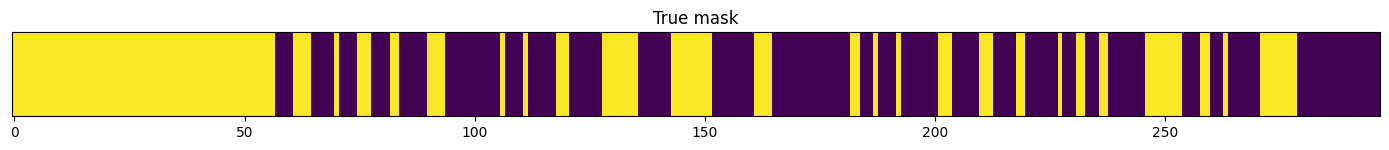

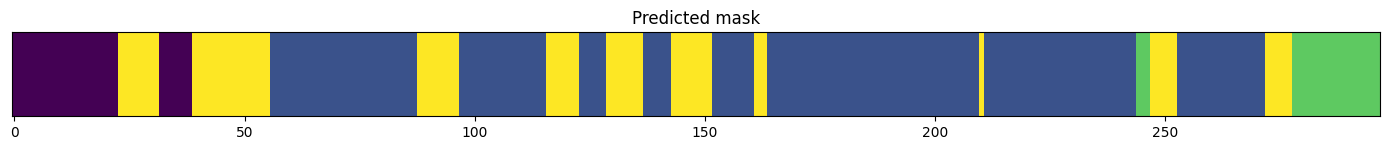

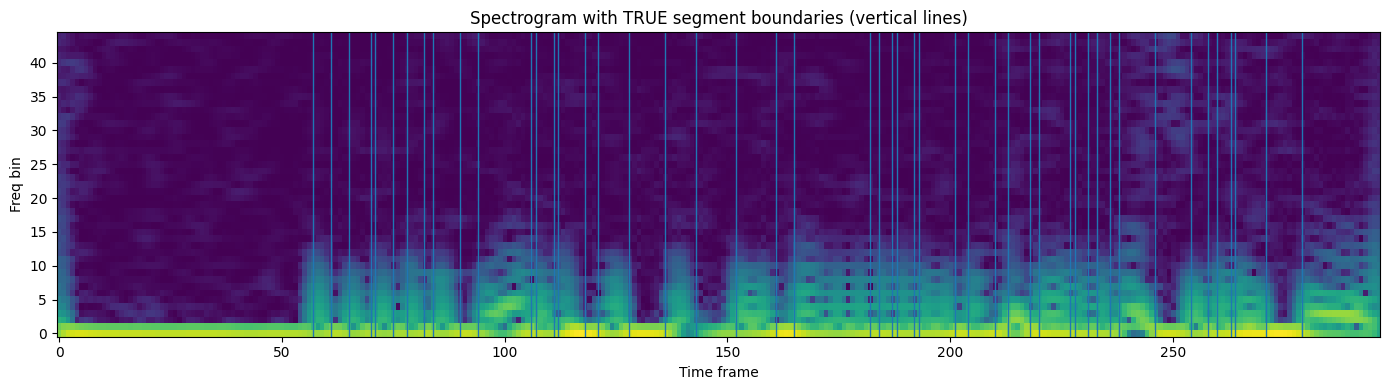

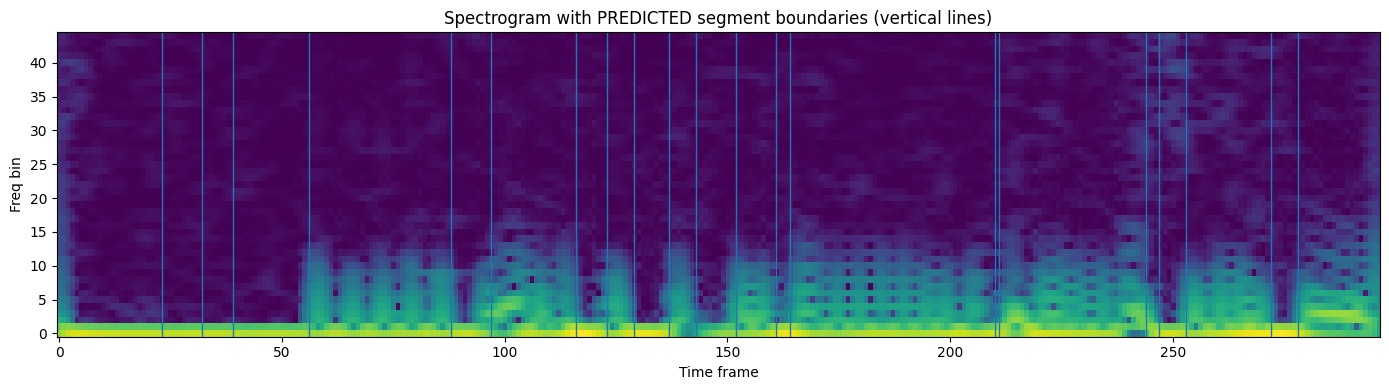

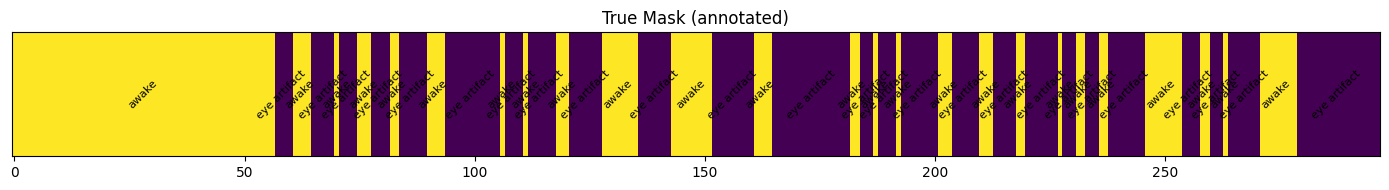

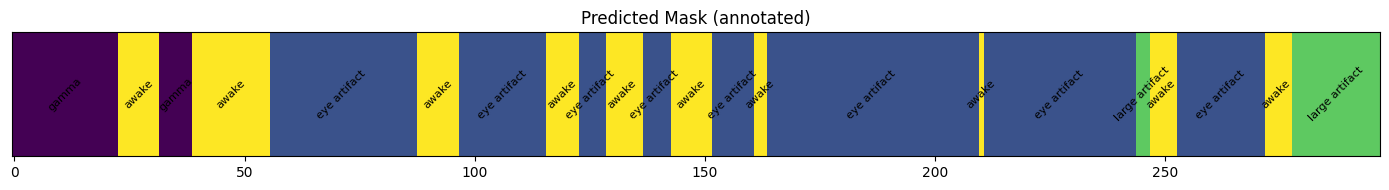

In [60]:
import numpy as np
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

idx = 15

# Already preprocessed spectrogram (log1p + global z-norm)
x_norm = X_test[idx].astype(np.float32)   # (45,297)
y_true = y_test[idx]                      # (297,)

# Forward
x_t = torch.from_numpy(x_norm).unsqueeze(0).to(device)
with torch.no_grad():
    logits = model(x_t)                    # (1,297,C)
    probs = torch.softmax(logits, dim=-1)
    y_pred = logits.argmax(dim=-1).squeeze(0).cpu().numpy()

# Optional: recover "log1p scale" spectrogram for nicer visuals
# because: x_norm = (x_log - mean) / std  =>  x_log = x_norm*std + mean
x_log = x_norm * std + mean   # requires mean/std variables from your training cell


# ---------- Masks as stripes ----------
plt.figure(figsize=(14, 1.6))
plt.imshow(y_true[None, :], aspect="auto")
plt.yticks([])
plt.title("True mask")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 1.6))
plt.imshow(y_pred[None, :], aspect="auto")
plt.yticks([])
plt.title("Predicted mask")
plt.tight_layout()
plt.show()

# ---------- Overlay mask boundaries on spectrogram ----------
def segment_boundaries(mask_1d: np.ndarray):
    # indices where label changes
    return np.where(mask_1d[1:] != mask_1d[:-1])[0] + 1

true_bounds = segment_boundaries(y_true)
pred_bounds = segment_boundaries(y_pred)

plt.figure(figsize=(14, 4))
plt.imshow(x_log, aspect="auto", origin="lower")
for t in true_bounds:
    plt.axvline(t, linewidth=1)  # true boundaries
plt.title("Spectrogram with TRUE segment boundaries (vertical lines)")
plt.xlabel("Time frame")
plt.ylabel("Freq bin")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.imshow(x_log, aspect="auto", origin="lower")
for t in pred_bounds:
    plt.axvline(t, linewidth=1)  # predicted boundaries
plt.title("Spectrogram with PREDICTED segment boundaries (vertical lines)")
plt.xlabel("Time frame")
plt.ylabel("Freq bin")
plt.tight_layout()
plt.show()


annotate_mask(y_true, classes, title="True Mask (annotated)")
annotate_mask(y_pred, classes, title="Predicted Mask (annotated)")
